# **Data Preprocessing Missing Value Imputation**

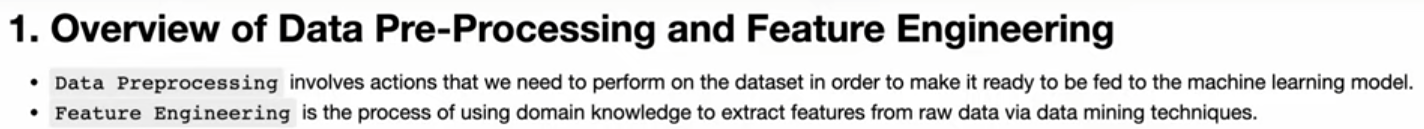

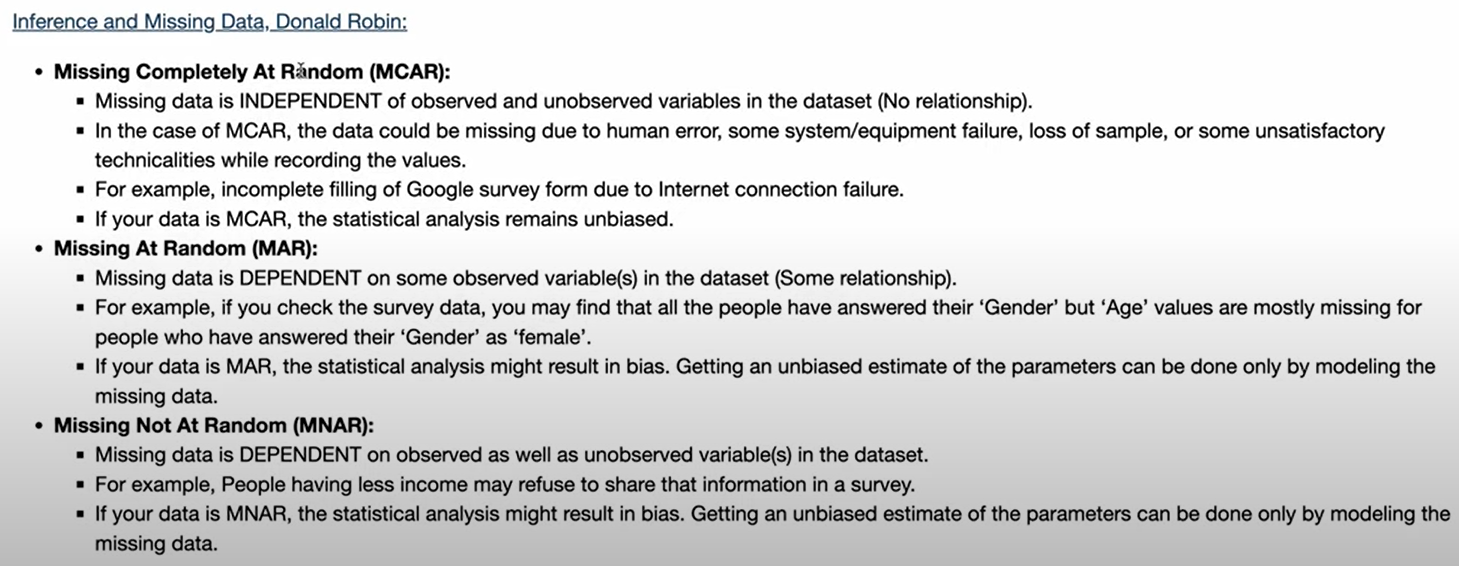

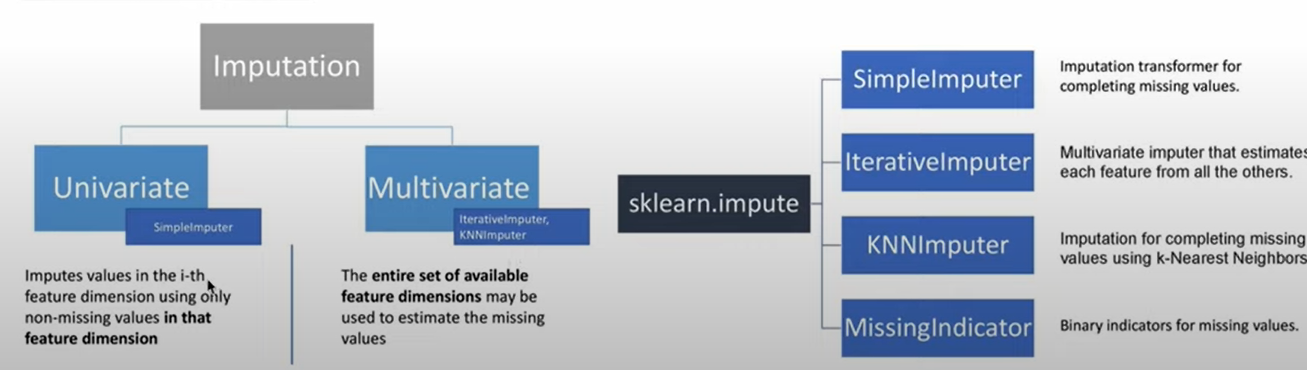

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\loan-eligibility.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [3]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
cols = [var for var in df.columns if df[var].isna().sum() > 0]
cols

['Gender',
 'Married',
 'Dependents',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [5]:
df.isna().sum().sum()

np.int64(149)

In [6]:
df.isna().mean() * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [7]:
# df.dropna(axis, how ,subset, inplace)
df1 = df.dropna(axis=1, how="any", inplace=False)
print(df1.shape)
df1.isnull().sum()

(614, 6)


Loan_ID              0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
Property_Area        0
Loan_Status          0
dtype: int64

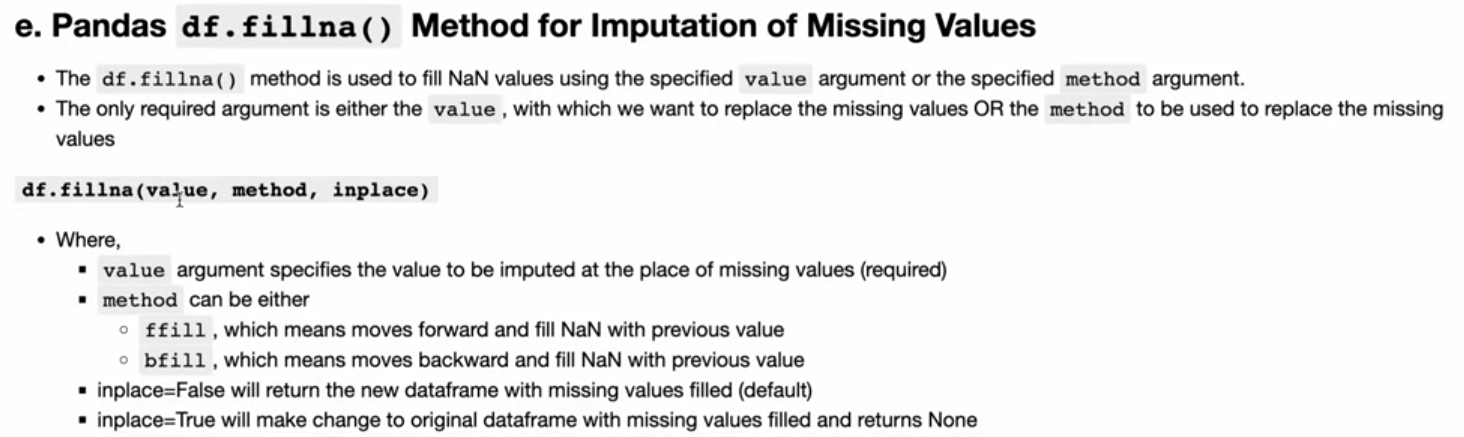

In [8]:
df1 = df.copy()
df1['Dependents'] = df1["Dependents"].fillna(value=0, inplace=False)
df1.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:

df1["LoanAmount"].mean()

np.float64(146.41216216216216)

In [10]:
df1["Credit_History"].mean()

np.float64(0.8421985815602837)

In [11]:
df1["LoanAmount"] = df1["LoanAmount"].fillna(value=df1["LoanAmount"].mean())
df1["Credit_History"] = df1["Credit_History"].fillna(value=df1["Credit_History"].mean())
df1.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

C:\Users\NoNeo\AppData\Local\Temp\ipykernel_8564\1015025866.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


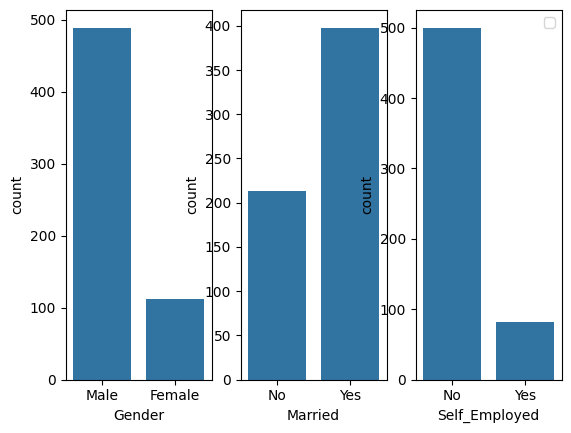

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3)
sns.countplot(x="Gender", data=df1, ax=ax1)
sns.countplot(x="Married", data=df1, ax=ax2)
sns.countplot(x="Self_Employed", data=df1, ax=ax3)
plt.legend()
plt.show()

In [13]:
df1["Gender"] = df1["Gender"].fillna(value=df1["Gender"].mode()[0])
df1["Married"] = df1["Married"].fillna(value=df1["Married"].mode()[0])
df1["Self_Employed"] = df1["Self_Employed"].fillna(value=df1["Self_Employed"].mode()[0])
df1.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
df1["Loan_Amount_Term"] = df1["Loan_Amount_Term"].fillna(value= df1["Loan_Amount_Term"].median())

In [15]:
df1.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

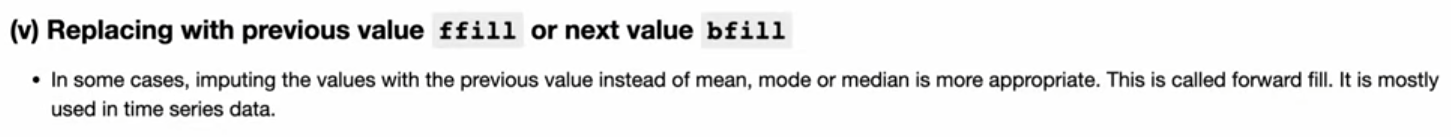

In [16]:
x = pd.Series(range(1,7))
x[2] = np.nan
x[4] = np.nan
x

0    1.0
1    2.0
2    NaN
3    4.0
4    NaN
5    6.0
dtype: float64

In [17]:
x.ffill(inplace=False)

0    1.0
1    2.0
2    2.0
3    4.0
4    4.0
5    6.0
dtype: float64

In [18]:
x.bfill(inplace=False)


0    1.0
1    2.0
2    4.0
3    4.0
4    6.0
5    6.0
dtype: float64

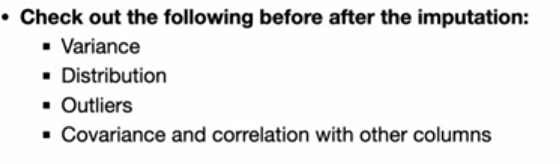

In [19]:
df["Loan_Amount_mean"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())
df["Loan_Amount_median"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

print("Loan Amount Original Data with missing values: ", np.var(df["LoanAmount"]))
print("Loan Amount Data with mean values: ", np.var(df["Loan_Amount_mean"]))
print("Loan Amount Data with median values: ", np.var(df["LoanAmount"]))

Loan Amount Original Data with missing values:  7312.816608838567
Loan Amount Data with mean values:  7050.793863896469
Loan Amount Data with median values:  7312.816608838567


C:\Users\NoNeo\AppData\Local\Temp\ipykernel_8564\1955477736.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


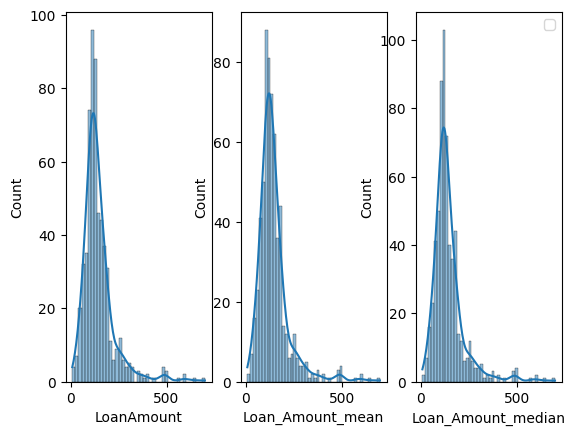

In [20]:
fig, (ax1, ax2,ax3) = plt.subplots(nrows=1, ncols=3)
sns.histplot(df["LoanAmount"], kde=True, ax=ax1)
sns.histplot(df["Loan_Amount_mean"], kde=True, ax=ax2)
sns.histplot(df["Loan_Amount_median"], kde=True, ax=ax3)
plt.legend()
plt.show()

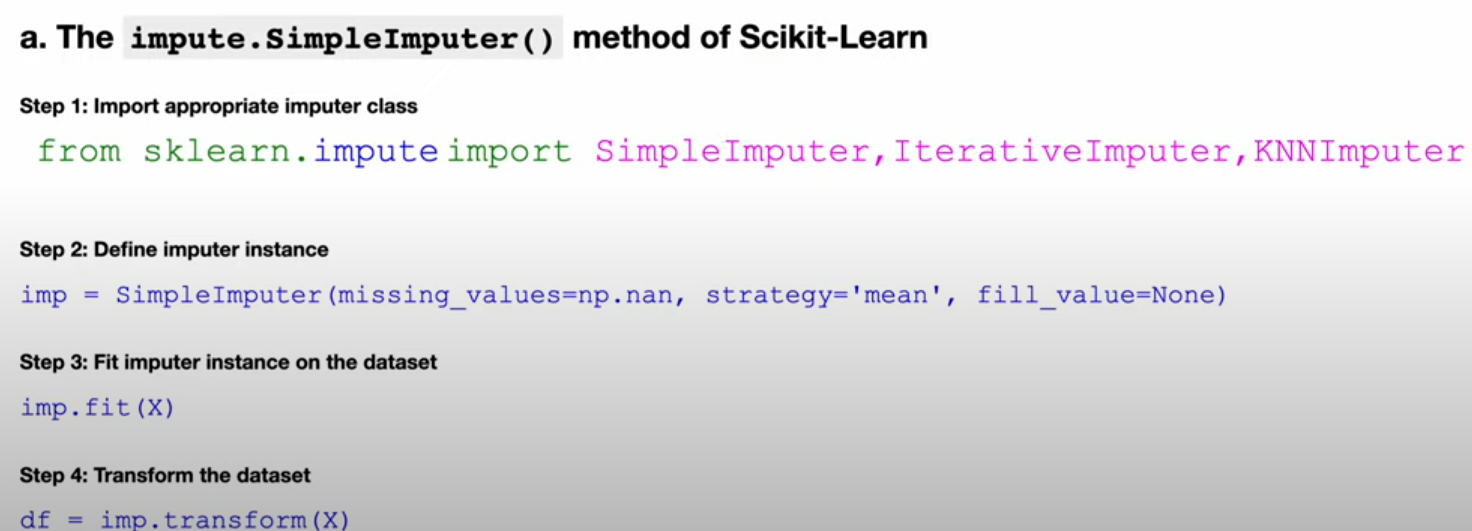

In [21]:
df.isna().sum()

Loan_ID                0
Gender                13
Married                3
Dependents            15
Education              0
Self_Employed         32
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
Loan_Amount_mean       0
Loan_Amount_median     0
dtype: int64

In [22]:
from sklearn.impute import SimpleImputer as si

imp = si(missing_values=np.nan, strategy='constant', fill_value=0)


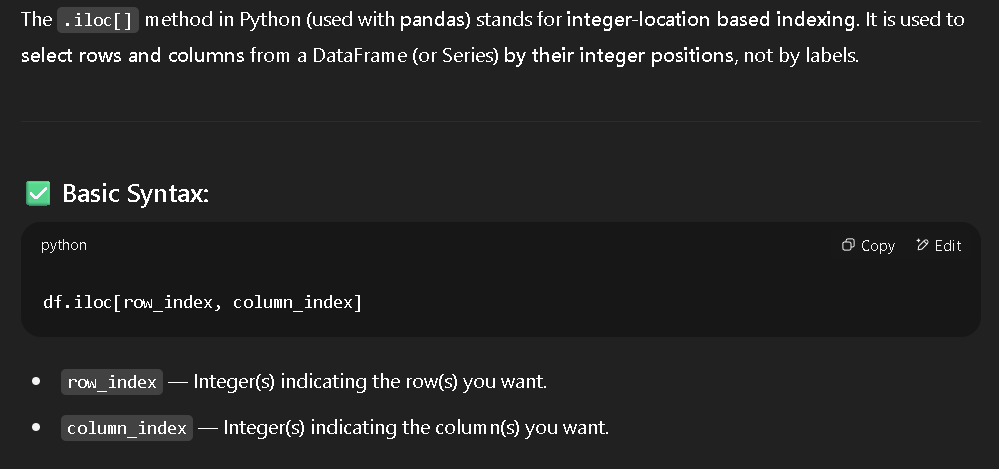

In [23]:
imp.fit(df.iloc[:,3:4])

SimpleImputer(fill_value=0, strategy='constant')

In [24]:
df.iloc[:,3:4] = imp.transform(df.iloc[:,3:4])

In [25]:
df.isna().sum()

Loan_ID                0
Gender                13
Married                3
Dependents             0
Education              0
Self_Employed         32
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
Loan_Amount_mean       0
Loan_Amount_median     0
dtype: int64

In [26]:
imp2 = si(missing_values=np.nan, strategy='most_frequent')


In [27]:
df.iloc[:,[1,2,5]] = imp2.fit_transform(df.iloc[:,[1,2,5]])


In [28]:
df.isnull().sum()

Loan_ID                0
Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
Loan_Amount_mean       0
Loan_Amount_median     0
dtype: int64

In [29]:
imp3 = si(missing_values=np.nan, strategy='mean')
df.iloc[:,8:11] = imp2.fit_transform(df.iloc[:,8:11])

In [30]:
df.isnull().sum()


Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
Loan_Amount_mean      0
Loan_Amount_median    0
dtype: int64

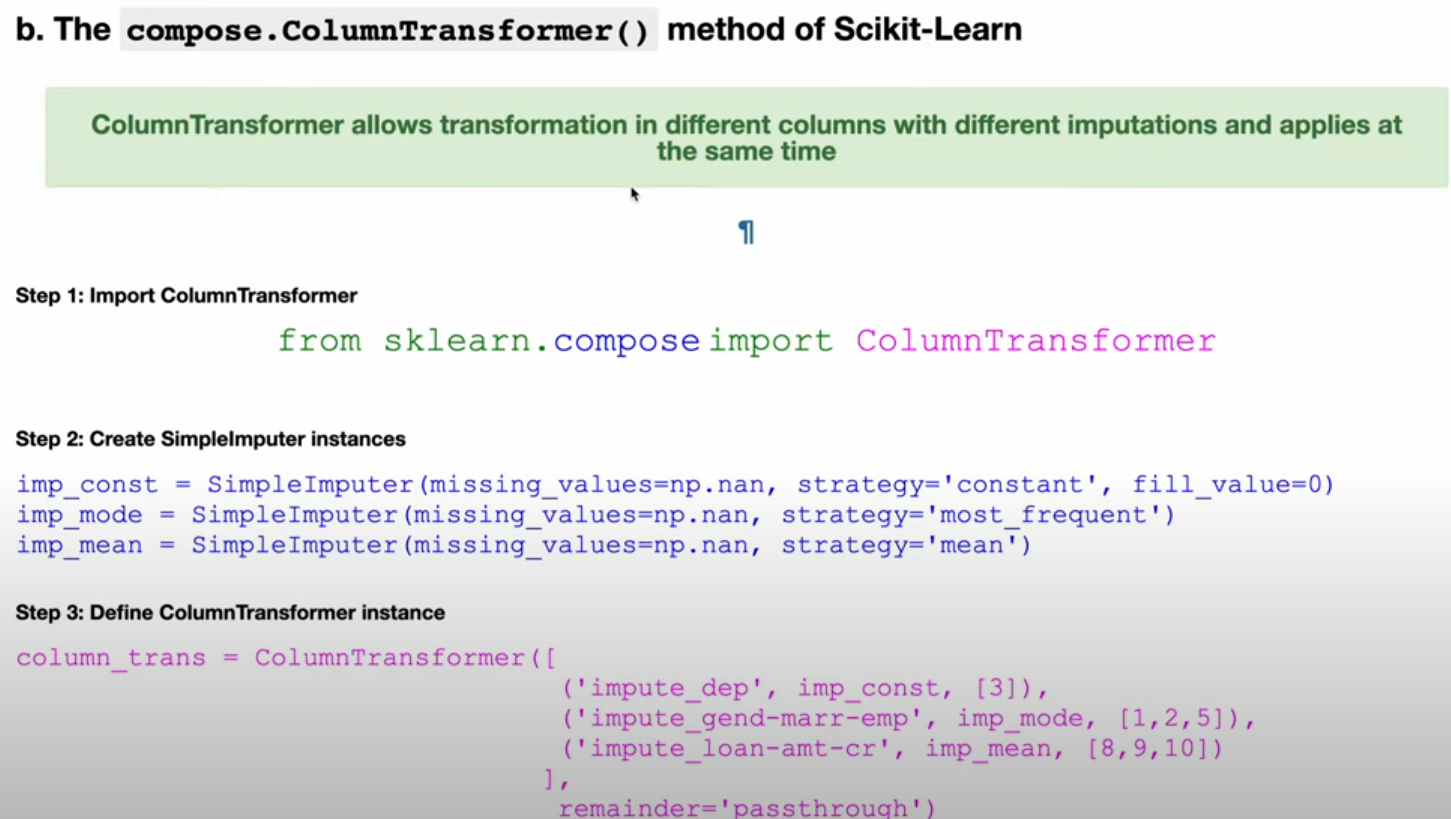

In [32]:
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\loan-eligibility.csv")
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

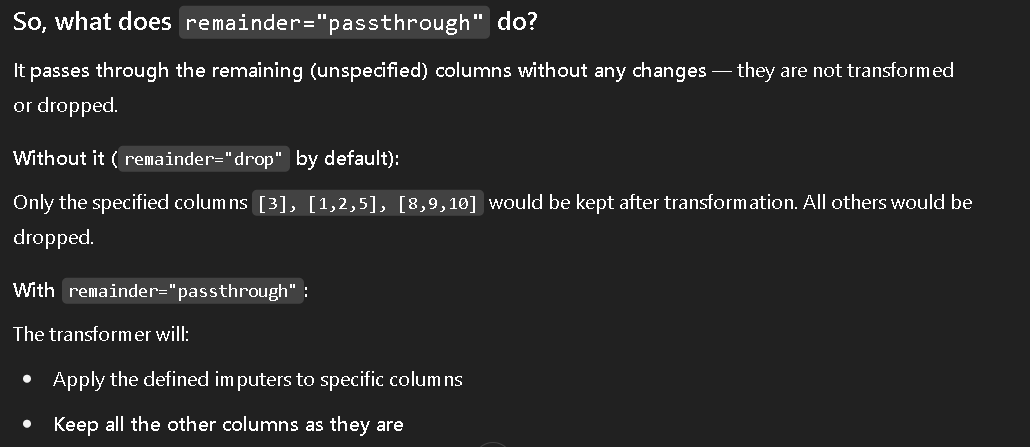

In [33]:
from sklearn.impute import SimpleImputer as si
from sklearn.compose import ColumnTransformer

imp_const = si(missing_values=np.nan, strategy="constant", fill_value=0)
imp_mode = si(missing_values=np.nan, strategy='most_frequent')
imp_mean = si(missing_values=np.nan, strategy='mean')

cols_trans = ColumnTransformer(
    [("impute_dept", imp_const, [3]),
     ("impute_G_M_E", imp_mode, [1,2,5]),
     ("impute_loan_amt_cr", imp_mean,[8,9,10])],
    remainder="passthrough"
) 

result = cols_trans.fit_transform(df)
print(result.shape)
print(result)

(614, 13)
[['0' 'Male' 'No' ... 0.0 'Urban' 'Y']
 ['1' 'Male' 'Yes' ... 1508.0 'Rural' 'N']
 ['0' 'Male' 'Yes' ... 0.0 'Urban' 'Y']
 ...
 ['1' 'Male' 'Yes' ... 240.0 'Urban' 'Y']
 ['2' 'Male' 'Yes' ... 0.0 'Urban' 'Y']
 ['0' 'Female' 'No' ... 0.0 'Semiurban' 'N']]


In [34]:
data_imputed = pd.DataFrame(data=result, columns=df.columns)
data_imputed.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

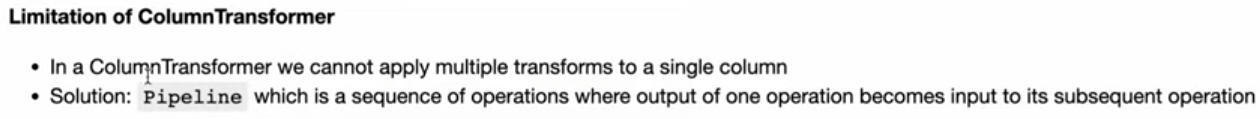

## **Multi-Variate Imputer**

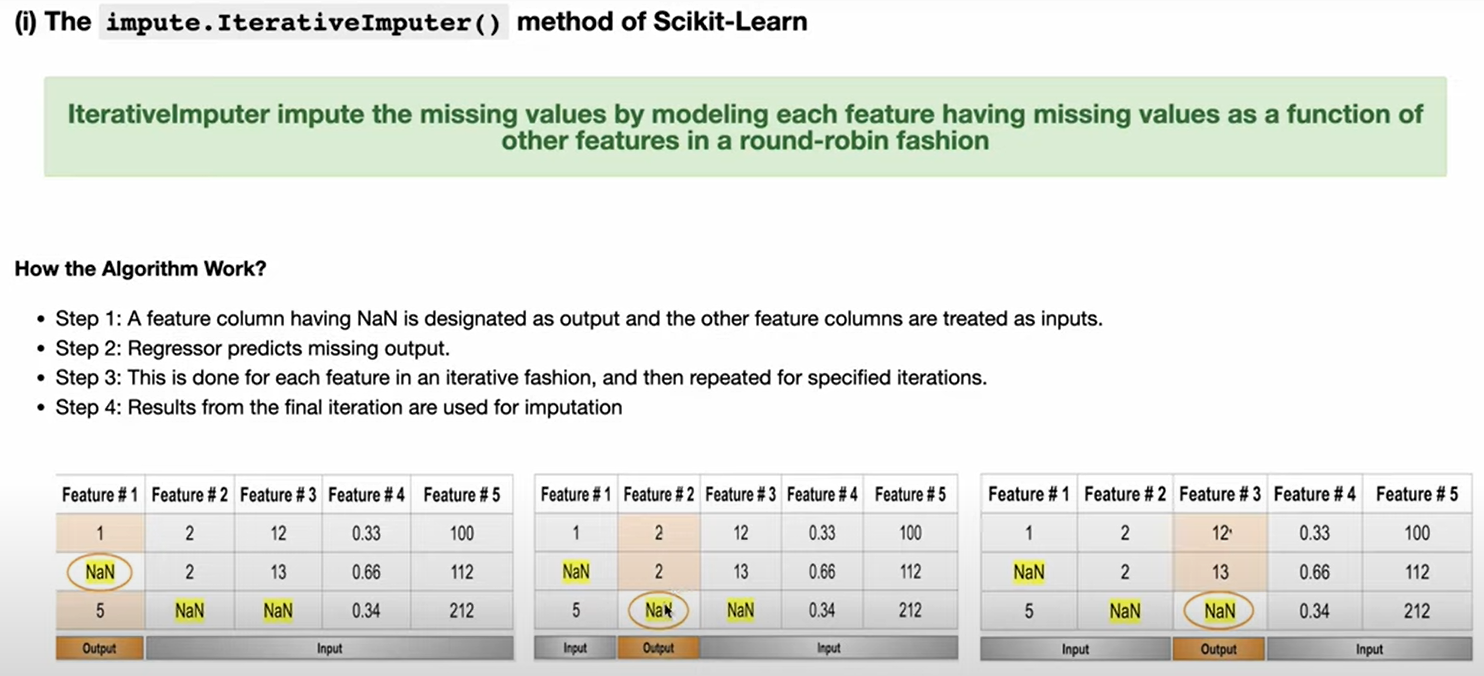

In [42]:
from  sklearn.linear_model import LinearRegression
lr = LinearRegression()

X = pd.DataFrame({
    'x1': [np.nan, 2, 3, 4, 5],
    'x2': [6, np.nan, 8, 9, 10],
    'x3': [11, 12, np.nan, 14, 15],
    'x4': [16, 17, 18, 19, np.nan]
})
X

,x1,x2,x3,x4
0,NaN,6.0,11.0,16.0
1,2.0,NaN,12.0,17.0
2,3.0,8.0,NaN,18.0
3,4.0,9.0,14.0,19.0
4,5.0,10.0,15.0,NaN


In [43]:

from  sklearn.experimental import enable_iterative_imputer
from  sklearn.impute import IterativeImputer
it_imp = IterativeImputer(
    estimator=lr, 
    missing_values=np.nan,
    initial_strategy='mean',
    max_iter=10
)
type(it_imp)


sklearn.impute._iterative.IterativeImputer

In [51]:
result = it_imp.fit_transform(X)

result

array([[ 1.,  6., 11., 16.],
       [ 2.,  7., 12., 17.],
       [ 3.,  8., 13., 18.],
       [ 4.,  9., 14., 19.],
       [ 5., 10., 15., 20.]])

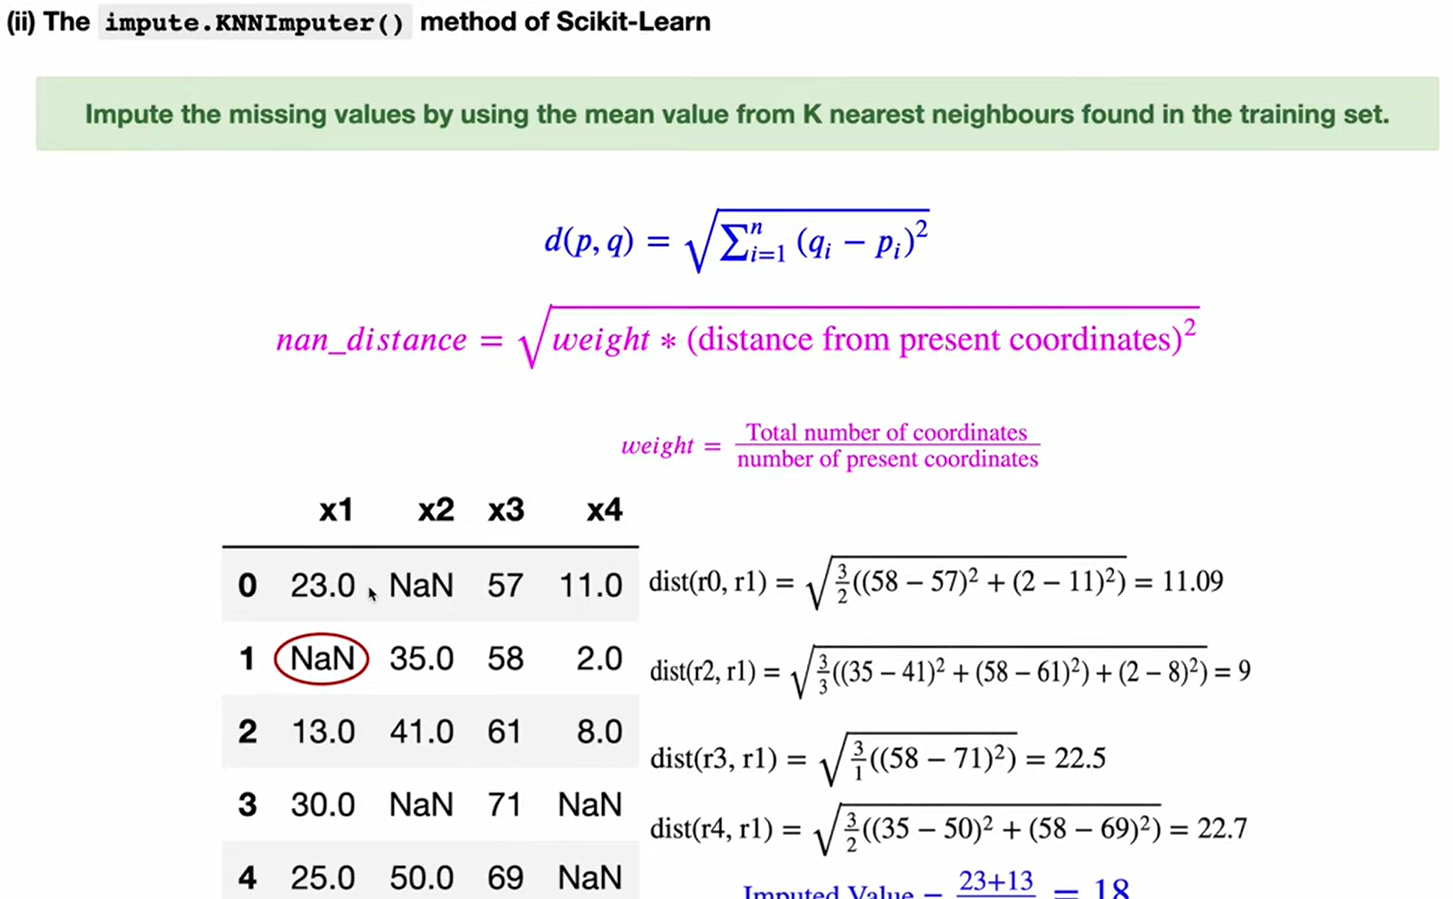

**Euclidean distance**
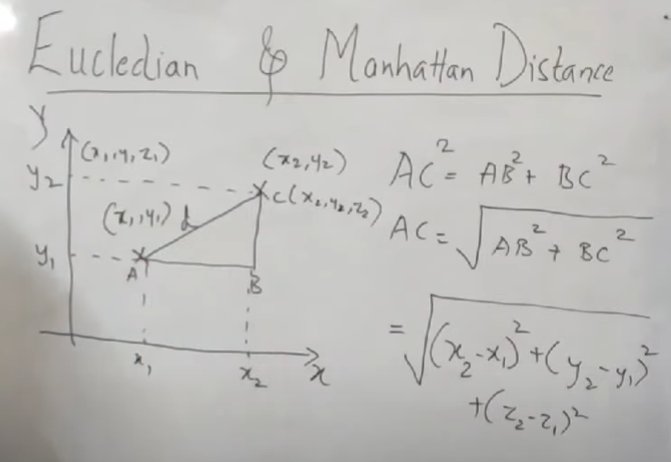
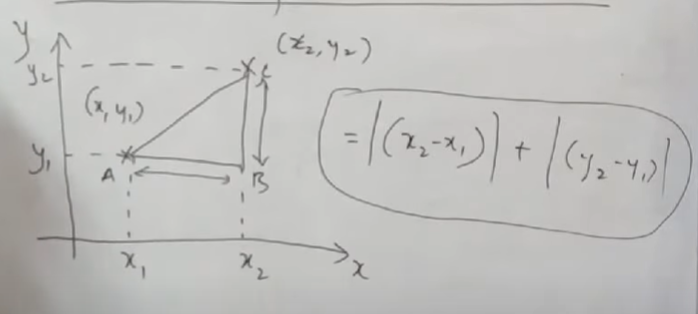

In [53]:
from sklearn.impute import KNNImputer

data = pd.DataFrame(
    {
        'x1': [23.0, np.nan, 13.0, 30.0, 25.0],
        'x2': [np.nan, 35.0, 41.0, np.nan, 50.0],
        'x3': [57, 58, 61, 71, 69],
        'x4': [11.0, 2.0, 8.0, np.nan, np.nan]
    }
)

In [58]:
kkn = KNNImputer(
    missing_values=np.nan ,
    n_neighbors=2,
    weights='uniform', 
    metric='nan_euclidean'
)

In [60]:
newdata=kkn.fit_transform(data)
newdata


array([[23. , 38. , 57. , 11. ],
       [18. , 35. , 58. ,  2. ],
       [13. , 41. , 61. ,  8. ],
       [30. , 42.5, 71. ,  6.5],
       [25. , 50. , 69. ,  9.5]])

## **HOW TO WORK with STRING datatypes in dataframe.**